In [1]:
import pandas as pd 
import numpy as  np 
import matplotlib.pyplot as   plt 
import seaborn as sns


import ot
from scipy.stats import gaussian_kde, norm
from sklearn.preprocessing import StandardScaler
from collections import deque

from scipy.stats import ks_2samp

import sys

sys.path.append('./source')


2026-01-28 13:28:28.086404: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-28 13:28:28.101739: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769603308.127090   20839 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769603308.134536   20839 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769603308.154555   20839 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769603308.154583   20839 computation_placer.cc:177] computation placer already registered. Please che

In [2]:
from mrot import  MassRepulsiveOptimalTransport

In [7]:
from sklearn.metrics import roc_auc_score


class OfflineMROT:
    # Cette classe implémente la version hors ligne de l'algorithme MROT pour la détection d'anomalies.
    def __init__(self, mrot_params={}):
        self.mrot_params = mrot_params
        self.mrot_offline = MassRepulsiveOptimalTransport()
        
    
    def train_mrot_offline(self, data):
        self.mrot_offline.fit(data)
    
    
    def predict(self, data):
        scores = self.mrot_offline.predict(data)
        return scores
    
    def auc_score(self, y_true, y_scores):
        return roc_auc_score(y_true, y_scores)
    
    

In [8]:
df  = pd.read_csv('glass_shake_sudden_2.csv')

In [9]:
df.head()

,5.239219999999999988e-01,4.058479999999999865e-01,8.148499999999999632e-01,2.992909999999999737e-01,8.110829999999999984e-01,8.929199999999999637e-02,2.526999999999999802e-01,0.000000000000000000e+00,0.000000000000000000e+00.1,0.000000000000000000e+00.2,0.000000000000000000e+00.3
0,0.610833,0.464432,0.830068,0.183840,0.650862,0.028340,0.382855,0.0,0.137293,0.0,0.0
1,0.438784,0.307055,0.759237,0.377213,0.898047,0.104295,0.236319,0.0,0.465393,0.0,0.0
2,0.435781,0.284788,0.786555,0.302206,0.882878,0.090147,0.272006,0.0,0.000000,0.0,0.0
3,0.571032,0.381863,0.807348,0.173921,0.695175,0.029813,0.401643,0.0,0.332295,0.0,0.0
4,0.438784,0.307055,0.759237,0.377213,0.898047,0.104295,0.236319,0.0,0.465393,0.0,0.0


In [10]:
df.shape

(49999, 11)

# Test offline

In [11]:
online  =OfflineMROT()
online.train_mrot_offline(df.iloc[:2000,1:6])
score = online.predict(df.iloc[:2000,1:6])

In [12]:
df.iloc[:2000,1:6].shape

(2000, 5)

In [13]:
train = df.iloc[:2000,1:6]

In [14]:
test = pd.DataFrame(df.iloc[:, -2:]).reset_index(drop=True)

In [15]:
test.iloc[:2000,-2].value_counts()

0.000000000000000000e+00.2
0.0    1962
1.0      38
Name: count, dtype: int64

In [16]:
y_test = test.iloc[:2000,-2].values

In [17]:
online.auc_score(y_test, score)

0.9371613283974461

In [18]:
test[test.columns[1]].value_counts()

0.000000000000000000e+00.3
0.0    49995
1.0        4
Name: count, dtype: int64

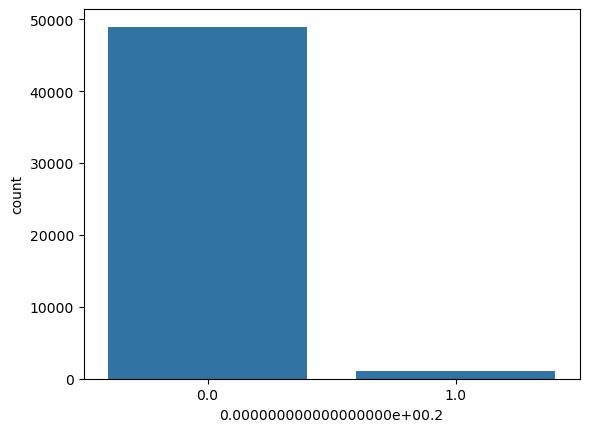

In [19]:
order = test[test.columns[0]].value_counts().index

sns.countplot(
    x=test.columns[0],
    data=test,
    order=order
)

plt.show()


In [20]:
#df.iloc[:10000,1:6].to_csv('data.csv', index=False)

#df.iloc[:2000,1:6].to_csv('data_offline.csv', index=False)    

# Developpement online

In [ ]:
class OnlineMROTAD : 
    
    def __init__(self, 
                 mrot_params = {}, # paramètres de l'algorithme MROT
                 window_size=1000, # taille de la fenêtre glissante pour les données en ligne
                 n_history = 10, # nombre de fenêtres historiques à conserver
                 m_barycenter = 5, # nombre d'anciennnes fenetres pour le barycentre de Wasserstein
                 theta_validation=0.80, # seuil de validation pour la mise à jour du modèle du modèle MROT
                 tau_anomaly = 0.85, # seuil de détection d'anomalies
                 K_retrain=5, # nombre de fenetres utilisées pour la reformation de MROT
                 data_online = None,
                 y_true_online = None,
                 data_offline = None,
                 y_true_offline = None
                 ):
        self.mrot_params = mrot_params
        self.window_size = window_size
        self.data_window = deque(maxlen=window_size)
        n_history = n_history
        self.m_barycenter = m_barycenter
        self.theta_validation = theta_validation
        self.tau_anomaly = tau_anomaly
        self.K_retrain = K_retrain
        self.auc_scores = []  # liste pour stocker les scores AUC au fil du temps
        
        self.online_data = data_online
        self.online_labels = y_true_online  
        self.offline_data = data_offline
        self.offline_labels = y_true_offline
        
        self.mrot_model = OfflineMROT(mrot_params=self.mrot_params)
        
    
    def fit_initial_model(self):
        self.mrot_model.train_mrot_offline(self.offline_data)
        score =  self.mrot_model.predict(self.offline_data)
        print(f"Anomaly scores for initial data computed. AUC Score: {self.mrot_model.auc_score(self.offline_labels, score)}")
        
        
        
    def ADWIN_detector(self, previous_window, current_window):
        # Implémentation simplifiée de ADWIN pour la détection de dérive
        
        p_values = []
        for feature_idx in range(previous_window.shape[1]):
            stat, p_value = ks_2samp(previous_window[:, feature_idx], current_window[:, feature_idx])
            p_values.append(p_value)
        
        return p_values
        
        
    def online_version_fix_windows(self ):
        
        
        pass

In [22]:
od = OnlineMROTAD(
    mrot_params={},
    window_size=1000,
    n_history = 10,
    m_barycenter = 5,
    theta_validation=0.80,
    tau_anomaly = 0.85,
    K_retrain=5,
    data_online = df.iloc[2000:4000,1:6],
    y_true_online = df.iloc[2000:4000,-2].values,
    data_offline = df.iloc[:2000,1:6],
    y_true_offline = df.iloc[:2000,-2].values
)


In [23]:
od.fit_initial_model()

Anomaly scores for initial data computed. AUC Score: 0.9371613283974461


In [24]:
#!pip install river

In [25]:
import random
from river import drift

adwin = drift.ADWIN()

data_stream =train.copy()

for i, val in enumerate(data_stream):
    adwin.update(val)
    if adwin.drift_detected:
        print(f"Change detected at index {i}, input value: {val}")

TypeError: must be real number, not str

In [ ]:


for index, row in train.iterrows():
    
    print(f"Index: {index}")
    print(f"Row data: {row.values}")
    break

Index: 0
Row data: [0.464432 0.830068 0.18384  0.650862 0.02834 ]


In [44]:
data_window = deque(maxlen=200)
data_test_window = deque(maxlen=200)

online = OfflineMROT()
online.train_mrot_offline(df.iloc[:2000, 1:6])
score = online.predict(df.iloc[:2000, 1:6])
score_list = []

# Sauvegarder les noms de colonnes pour les réutiliser
feature_columns = df.columns[1:6]  # Les colonnes utilisées pour l'entraînement

for index in train.index:
    data_window.append(train.loc[index].values)
    data_test_window.append(y_test[index])
    
    print(f"Current window size: {len(data_window)}")
    if len(data_window) == data_window.maxlen:
        print("Window is full. Processing data...")
        
        # Convertir en DataFrame avec les noms de colonnes appropriés
        data_df = pd.DataFrame(np.array(data_window), columns=feature_columns)
        online_scores = online.predict(data_df)
        
        # Check if data_test_window contains at least two classes
        if len(set(data_test_window)) > 1:
            print(data_test_window)
            auc_score = roc_auc_score(data_test_window, online_scores)
            score_list.append(auc_score)
            print(f"AUC Score for current window: {auc_score}")
        else:
            print("Skipping AUC calculation: Only one class present in data_test_window.")
        
        data_window.clear()
        data_test_window.clear()

Current window size: 1
Current window size: 2
Current window size: 3
Current window size: 4
Current window size: 5
Current window size: 6
Current window size: 7
Current window size: 8
Current window size: 9
Current window size: 10
Current window size: 11
Current window size: 12
Current window size: 13
Current window size: 14
Current window size: 15
Current window size: 16
Current window size: 17
Current window size: 18
Current window size: 19
Current window size: 20
Current window size: 21
Current window size: 22
Current window size: 23
Current window size: 24
Current window size: 25
Current window size: 26
Current window size: 27
Current window size: 28
Current window size: 29
Current window size: 30
Current window size: 31
Current window size: 32
Current window size: 33
Current window size: 34
Current window size: 35
Current window size: 36
Current window size: 37
Current window size: 38
Current window size: 39
Current window size: 40
Current window size: 41
Current window size: 42
C

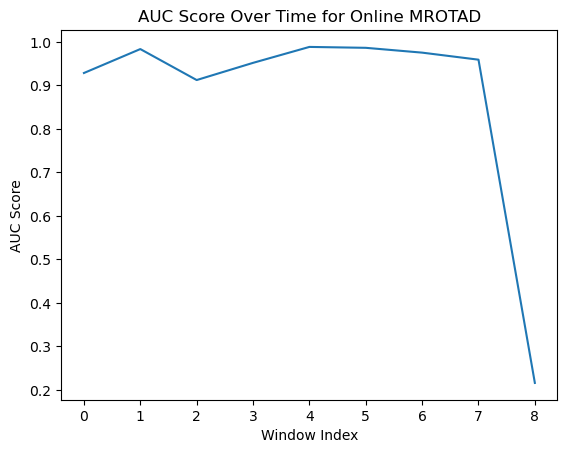

In [45]:
sns.lineplot(x=range(len(score_list)), y=score_list)
plt.xlabel("Window Index")
plt.ylabel("AUC Score")
plt.title("AUC Score Over Time for Online MROTAD")
plt.show()

In [47]:
from scipy.stats import ks_2samp
import numpy as np

data_window = deque(maxlen=200)
data_test_window = deque(maxlen=200)
previous_window = None  # Pour stocker la fenêtre précédente pour la comparaison

online = OfflineMROT()
online.train_mrot_offline(df.iloc[:2000, 1:6])
score = online.predict(df.iloc[:2000, 1:6])
score_list = []
drift_detected_list = []

feature_columns = df.columns[1:6]

drift_threshold = 0.05  # Seuil p-value pour le test de Kolmogorov-Smirnov
performance_threshold = 0.7  # Seuil AUC en dessous duquel on réentraîne

for index in train.index:
    data_window.append(train.loc[index].values)
    data_test_window.append(y_test[index])
        
    if len(data_window) == data_window.maxlen:
        print("Window is full. Processing data...")
        
        data_df = pd.DataFrame(np.array(data_window), columns=feature_columns)
        online_scores = online.predict(data_df)
        
        drift_detected = False
        
        # 1. Détection de drift par test statistique (Kolmogorov-Smirnov)
        if previous_window is not None:
            print("Checking for concept drift...")
            p_values = []
            
            # Test KS pour chaque feature
            for i in range(len(feature_columns)):
                current_feature = np.array(data_window)[:, i]
                previous_feature = previous_window[:, i]
                _, p_value = ks_2samp(current_feature, previous_feature)
                p_values.append(p_value)
            
            # Drift détecté si au moins une feature a une p-value < seuil
            min_p_value = min(p_values)
            if min_p_value < drift_threshold:
                drift_detected = True
                print(f" DRIFT DETECTED! Min p-value: {min_p_value:.4f}")
        
        # 2. Vérification de la performance
        if len(set(data_test_window)) > 1:
            auc_score = roc_auc_score(data_test_window, online_scores)
            score_list.append(auc_score)
            print(f"AUC Score for current window: {auc_score:.4f}")
            
            # Drift détecté si performance dégradée
            if auc_score < performance_threshold:
                drift_detected = True
                print(f" PERFORMANCE DRIFT! AUC below threshold: {auc_score:.4f}")
        else:
            print("Skipping AUC calculation: Only one class present in data_test_window.")
            auc_score = None
        
        drift_detected_list.append(drift_detected)
        
        # 3. Mise à jour du modèle si drift détecté
        if drift_detected:
            print(" Retraining model with current window...")
            
            # Créer un DataFrame avec labels pour le réentraînement
            retrain_df = data_df.copy()
            retrain_df['label'] = list(data_test_window)
            
            # Réentraîner le modèle
            online.train_mrot_offline(retrain_df.iloc[:, :-1])  # Sans la colonne label
            print(" Model retrained successfully!")
        
        previous_window = np.array(data_window).copy()
        
        data_window.clear()
        data_test_window.clear()

print(f"Total windows processed: {len(score_list)}")
print(f"Drift detected: {sum(drift_detected_list)} times")
print(f"Average AUC: {np.mean([s for s in score_list if s is not None]):.4f}")


Window is full. Processing data...
AUC Score for current window: 0.9286
Window is full. Processing data...
Checking for concept drift...
AUC Score for current window: 0.9836
Window is full. Processing data...
Checking for concept drift...
AUC Score for current window: 0.9124
Window is full. Processing data...
Checking for concept drift...
AUC Score for current window: 0.9519
Window is full. Processing data...
Checking for concept drift...
AUC Score for current window: 0.9885
Window is full. Processing data...
Checking for concept drift...
AUC Score for current window: 0.9865
Window is full. Processing data...
Checking for concept drift...
Skipping AUC calculation: Only one class present in data_test_window.
Window is full. Processing data...
Checking for concept drift...
AUC Score for current window: 0.9754
Window is full. Processing data...
Checking for concept drift...
AUC Score for current window: 0.9592
Window is full. Processing data...
Checking for concept drift...
AUC Score for 